# Zomato Data Analysis Using Python

# Step - 1 : Import Necessary Python Libraries.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step - 2 : Create The Data Frame.

In [6]:
df = pd.read_csv("Zomato data .csv")

In [7]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [8]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


# Let's Convert The Data Type Of The "Rate" Column to float And Remove The Denominator .

In [9]:
def remove(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

In [10]:
df['rate'] = df['rate'].apply(remove)

In [11]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


# Summary of the data

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [13]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Conclusion - There is no NULL Values in the data frame

In [14]:
df.duplicated().sum()

np.int64(0)

Conclusion - There is no Duplicated Values in the data frame

# Business Problem Solved

# Q.1

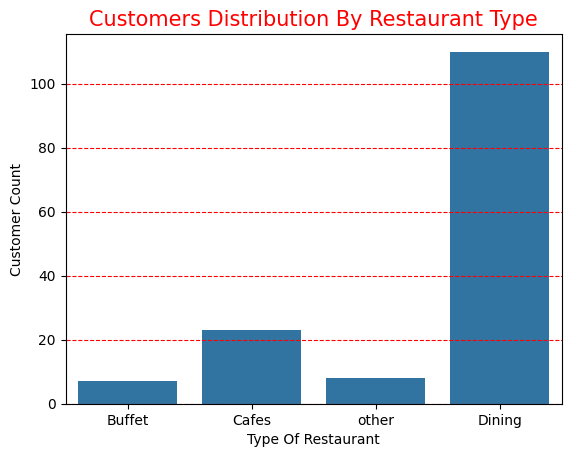

In [31]:
sns.countplot(x=df['listed_in(type)'] )
plt.title('Customers Distribution By Restaurant Type' , c = 'Red' , size= 15 )
plt.xlabel('Type Of Restaurant')
plt.ylabel('Customer Count')
plt.grid(axis='y',linestyle = '--' , c= 'red')
plt.show()

# Conclusion :- The Majority Of The Restaurants Fall into The Dining Category. And Dining are preferred by a larger number of individuals .

# Q.2

In [17]:
Group_by = df.groupby(by= 'listed_in(type)')['votes'].sum()
print(Group_by)

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64


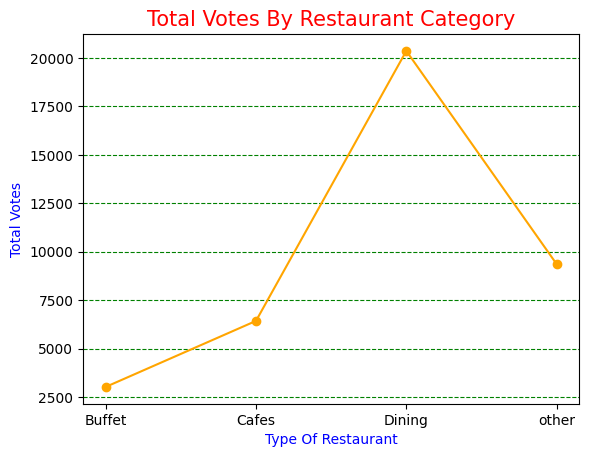

In [69]:
result = pd.DataFrame({'votes' : Group_by})
plt.plot(result , c="orange" , marker = "o" )
plt.title('Total Votes By Restaurant Category' , color = "Red",size = 15)
plt.xlabel("Type Of Restaurant" , c= "blue")
plt.ylabel("Total Votes" , c= "blue")
plt.grid(axis='y',linestyle='--',c= "green")
plt.show()

# The Majority of restaurants received ratings

# Q.3

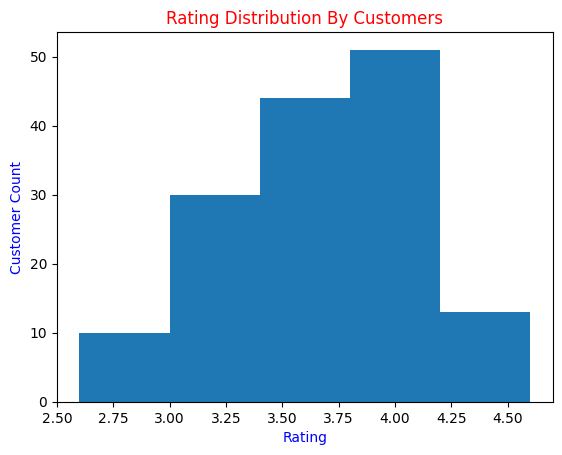

In [70]:
plt.hist(df['rate'],bins=5)
plt.title("Rating Distribution By Customers", c ="red")
plt.xlabel("Rating" ,c="blue")
plt.ylabel("Customer Count" , c= 'blue')
plt.show()

# conclusion :- The majority of restaurants recevies ratings ranging from 3.5 to 4 

# Q.4 

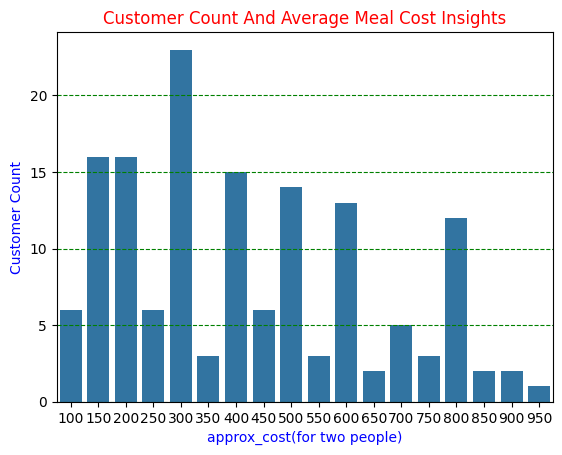

In [73]:
couples_data = df['approx_cost(for two people)']
sns.countplot(x=couples_data)
plt.title("Customer Count And Average Meal Cost Insights",c='red')
plt.xlabel("approx_cost(for two people)" ,c='blue')
plt.ylabel("Customer Count",c='blue')
plt.grid(axis='y',linestyle = '--',color = 'green')

# The Majority of couples prefer restaurants with an approximate cost of 300 rupees

# Q.5

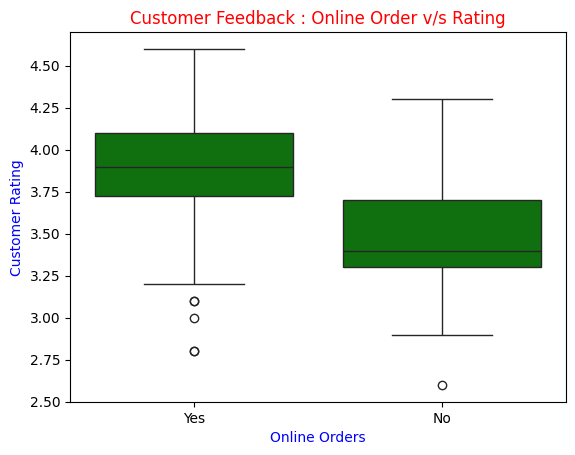

In [59]:
plt.Figure(figsize=(6,6))
sns.boxplot(data=df , x='online_order',y='rate' , color="green")
plt.title('Customer Feedback : Online Order v/s Rating' , c ='red' )
plt.xlabel('Online Orders', c='blue' )
plt.ylabel('Customer Rating',c='blue')
plt.show()

# Conclusion :- Offline orders received lower ratings in comparison online orders 

# Q.6

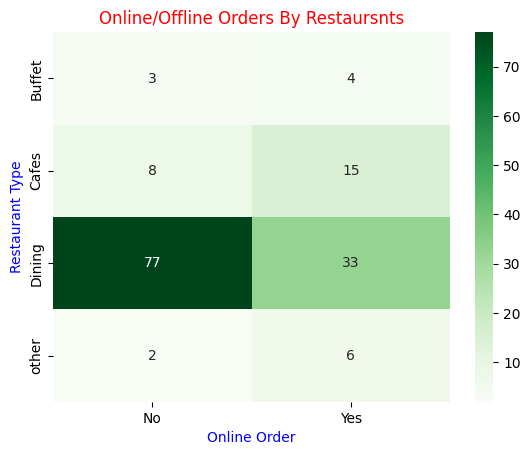

In [63]:
pivot = df.pivot_table(index='listed_in(type)',columns = 'online_order', aggfunc = 'size' , fill_value = 0 )
sns.heatmap(pivot , annot=True, cmap='Greens' , fmt= 'd')
plt.title('Online/Offline Orders By Restaursnts' , c ='red')
plt.xlabel('Online Order',c='blue')
plt.ylabel('Restaurant Type', c='blue')
plt.show()

# Conclusion :- Dining restaurants primarily accept offline orders , where as cafes primarily recevied online orders . This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes